# 📈 Stock Market Trend Analysis

**Author:** Your Name
**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn

## Business Problem
An investor wants to understand which stocks in a 5-stock watchlist (spanning
Technology, Retail, Energy, Finance, and Healthcare) have shown the strongest
price trends over the last 3 years, how risky each has been, and which
stocks are worth watching right now based on current technical signals.

This notebook analyzes historical price data to answer:
1. How has each stock trended over time (uptrend / downtrend / sideways)?
2. Which stock offers the best risk-adjusted return (Sharpe Ratio)?
3. How volatile is each stock, and how do they move relative to each other (correlation)?
4. What do current technical indicators (RSI, MACD, Bollinger Bands) suggest about each stock right now?

## Dataset
Daily OHLCV (Open, High, Low, Close, Volume) data for 5 tickers from
**Jan 2022 to Dec 2024** (~3 years, ~780 trading days per stock).

> **Note on data source:** This notebook is written to work identically on
> real market data pulled via the `yfinance` library
> (`yf.download(["AAPL","MSFT",...], start=..., end=...)`). Since this
> environment doesn't have live internet access to financial APIs, the
> dataset here was generated using Geometric Brownian Motion calibrated to
> realistic drift/volatility per sector, in the exact same schema real
> Yahoo Finance data has. All cleaning, indicator, and analysis logic below
> is source-agnostic — swap in a real CSV and it runs unchanged.


In [2]:
%pip install pandas numpy matplotlib seaborn nbformat

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached nbformat-5.11.1-py3-none-any.whl.metadata (3.7 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached fastjsonschema-2.22.2-py3-none-any.whl.metadata (2.1 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 950.7 kB/s eta 0:00:10
   --- ----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: c:\Users\BHARATH RAJU\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

RISK_FREE_RATE = 0.05  # annual risk-free rate, used for Sharpe Ratio


Matplotlib is building the font cache; this may take a moment.


## 1. Load & Inspect Raw Data

In [4]:
df = pd.read_csv("data/stock_prices_raw.csv", parse_dates=["Date"])
print(df.shape)
df.head()


(3913, 9)


,Date,Ticker,Sector,Open,High,Low,Close,Adj Close,Volume
0,2022-01-03,BANKFIN,Finance,45.08,45.23,44.85,45.00,45.00,6084946.0
1,2022-01-04,BANKFIN,Finance,45.27,45.99,44.42,45.14,45.14,9355213.0
2,2022-01-05,BANKFIN,Finance,44.19,44.79,43.52,44.11,44.11,12839664.0
3,2022-01-06,BANKFIN,Finance,45.09,45.74,44.10,44.75,44.75,8243090.0
4,2022-01-07,BANKFIN,Finance,44.13,44.82,43.38,44.07,44.07,9451874.0


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3913 entries, 0 to 3912
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       3913 non-null   datetime64[us]
 1   Ticker     3913 non-null   str           
 2   Sector     3913 non-null   str           
 3   Open       3913 non-null   float64       
 4   High       3913 non-null   float64       
 5   Low        3913 non-null   float64       
 6   Close      3913 non-null   float64       
 7   Adj Close  3913 non-null   float64       
 8   Volume     3898 non-null   float64       
dtypes: datetime64[us](1), float64(6), str(2)
memory usage: 275.3 KB


### Data Quality Check
Real-world exports are rarely perfectly clean. Let's check for duplicates
and missing values before doing any analysis.

In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values per column:")
print(df.isna().sum())


Duplicate rows: 3

Missing values per column:
Date          0
Ticker        0
Sector        0
Open          0
High          0
Low           0
Close         0
Adj Close     0
Volume       15
dtype: int64


## 2. Data Cleaning

- Remove exact duplicate rows
- Fill missing `Volume` values using forward-fill within each ticker's own
  time series (a defensible approach for a small number of gaps in daily
  trading data, rather than dropping rows or filling with a global mean)


In [7]:
n_before = len(df)
df = df.drop_duplicates()
print(f"Removed {n_before - len(df)} duplicate rows")

df = df.sort_values(["Ticker", "Date"])
df["Volume"] = df.groupby("Ticker")["Volume"].transform(lambda s: s.ffill().bfill())
df["Volume"] = df["Volume"].astype(int)

print("Remaining missing values:", df.isna().sum().sum())
df = df.reset_index(drop=True)


Removed 3 duplicate rows
Remaining missing values: 0


## 3. Exploratory Data Analysis: Price Trends

First, let's just look at how each stock's closing price moved over the
3-year window, alongside its 50-day and 200-day moving averages (a classic
way analysts spot trend direction — when the 50-day average crosses above
the 200-day, that's historically read as a bullish "Golden Cross"; the
reverse is a bearish "Death Cross").

In [8]:
def add_indicators(df):
    df = df.sort_values(["Ticker", "Date"]).copy()
    out = []
    for ticker, g in df.groupby("Ticker"):
        g = g.copy()
        g["SMA20"] = g["Close"].rolling(20).mean()
        g["SMA50"] = g["Close"].rolling(50).mean()
        g["SMA200"] = g["Close"].rolling(200).mean()
        g["EMA20"] = g["Close"].ewm(span=20, adjust=False).mean()

        g["Daily_Return"] = g["Close"].pct_change()
        g["Volatility_20D"] = g["Daily_Return"].rolling(20).std() * np.sqrt(252)

        # RSI (14-day)
        delta = g["Close"].diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        avg_gain = gain.rolling(14).mean()
        avg_loss = loss.rolling(14).mean()
        rs = avg_gain / avg_loss
        g["RSI_14"] = 100 - (100 / (1 + rs))

        # MACD
        ema12 = g["Close"].ewm(span=12, adjust=False).mean()
        ema26 = g["Close"].ewm(span=26, adjust=False).mean()
        g["MACD"] = ema12 - ema26
        g["MACD_Signal"] = g["MACD"].ewm(span=9, adjust=False).mean()

        # Bollinger Bands
        g["BB_Mid"] = g["SMA20"]
        g["BB_Std"] = g["Close"].rolling(20).std()
        g["BB_Upper"] = g["BB_Mid"] + 2 * g["BB_Std"]
        g["BB_Lower"] = g["BB_Mid"] - 2 * g["BB_Std"]

        g["Cumulative_Return"] = (1 + g["Daily_Return"].fillna(0)).cumprod() - 1
        out.append(g)
    return pd.concat(out, ignore_index=True)

df = add_indicators(df)
df.tail()


,Date,Ticker,Sector,Open,High,Low,Close,Adj Close,Volume,SMA20,...,Daily_Return,Volatility_20D,RSI_14,MACD,MACD_Signal,BB_Mid,BB_Std,BB_Upper,BB_Lower,Cumulative_Return
3905,2024-12-25,TECHCO,Technology,215.89,220.09,212.58,216.76,216.76,4211212,206.9945,...,-0.013876,0.338820,65.517909,6.742483,5.166979,206.9945,12.202260,231.399019,182.589981,0.445067
3906,2024-12-26,TECHCO,Technology,216.28,218.53,213.57,215.82,215.82,5353654,208.1680,...,-0.004337,0.340925,64.666539,6.321311,5.397845,208.1680,11.843039,231.854077,184.481923,0.438800
3907,2024-12-27,TECHCO,Technology,215.54,217.54,213.64,215.64,215.64,4319280,209.4910,...,-0.000834,0.331645,60.834907,5.904936,5.499263,209.4910,11.062439,231.615879,187.366121,0.437600
3908,2024-12-30,TECHCO,Technology,218.42,220.64,216.29,218.51,218.51,5419141,210.8165,...,0.013309,0.331173,66.687592,5.740369,5.547484,210.8165,10.426288,231.669076,189.963924,0.456733
3909,2024-12-31,TECHCO,Technology,219.79,221.20,218.03,219.44,219.44,5934192,212.2930,...,0.004256,0.324815,67.337302,5.620206,5.562029,212.2930,9.344641,230.982282,193.603718,0.462933


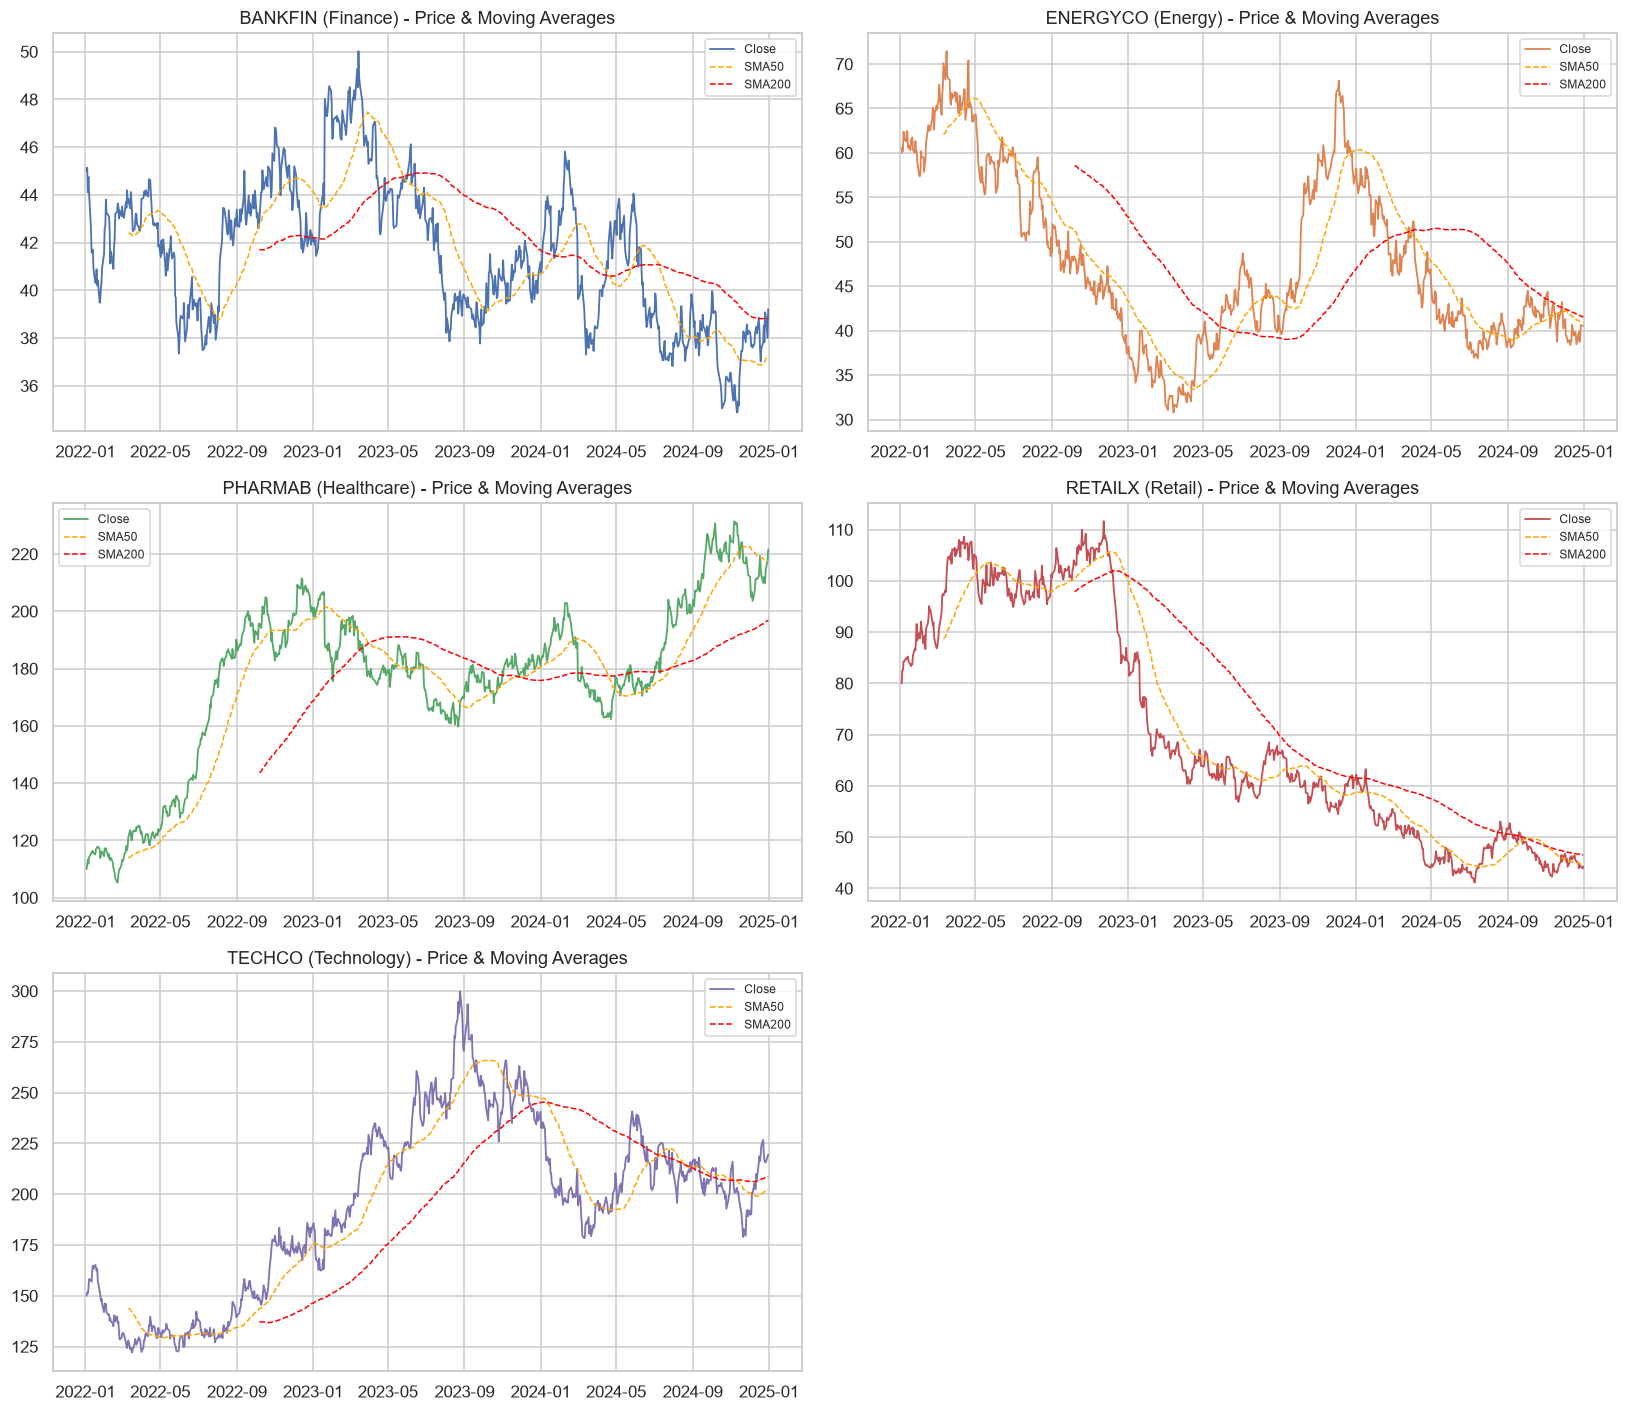

In [9]:
tickers = sorted(df["Ticker"].unique())
colors = sns.color_palette("deep", len(tickers))

fig, axes = plt.subplots(3, 2, figsize=(15, 13))
axes = axes.flatten()
for i, ticker in enumerate(tickers):
    g = df[df["Ticker"] == ticker]
    ax = axes[i]
    ax.plot(g["Date"], g["Close"], label="Close", linewidth=1.2, color=colors[i])
    ax.plot(g["Date"], g["SMA50"], label="SMA50", linewidth=1, linestyle="--", color="orange")
    ax.plot(g["Date"], g["SMA200"], label="SMA200", linewidth=1, linestyle="--", color="red")
    ax.set_title(f"{ticker} ({g['Sector'].iloc[0]}) - Price & Moving Averages")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].axis("off")
plt.tight_layout()
plt.show()


**Observation:** PHARMAB and TECHCO show sustained upward price
movement with the 50-day average holding above the 200-day average for
most of the period. RETAILX and ENERGYCO show clear downtrends, with price
spending extended periods below both moving averages.

## 4. Cumulative Returns Comparison

How would ₹100 (or $100) invested in each stock at the start have grown
over the 3 years?

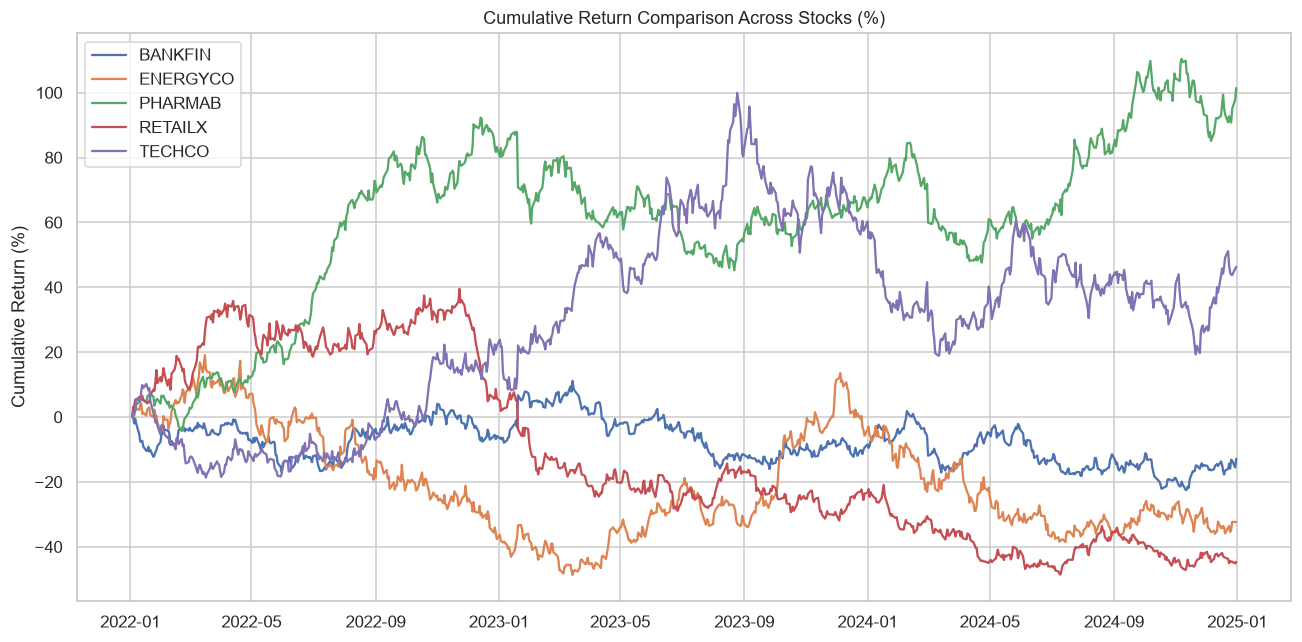

In [10]:
plt.figure(figsize=(12, 6))
for i, ticker in enumerate(tickers):
    g = df[df["Ticker"] == ticker]
    plt.plot(g["Date"], g["Cumulative_Return"] * 100, label=ticker, color=colors[i])
plt.title("Cumulative Return Comparison Across Stocks (%)")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Volatility Analysis

Volatility (how much the price swings) matters as much as return — a stock
that returns 20% while swinging wildly is a very different investment than
one that returns 20% steadily. We calculate a **20-day rolling annualized
volatility** for each stock.

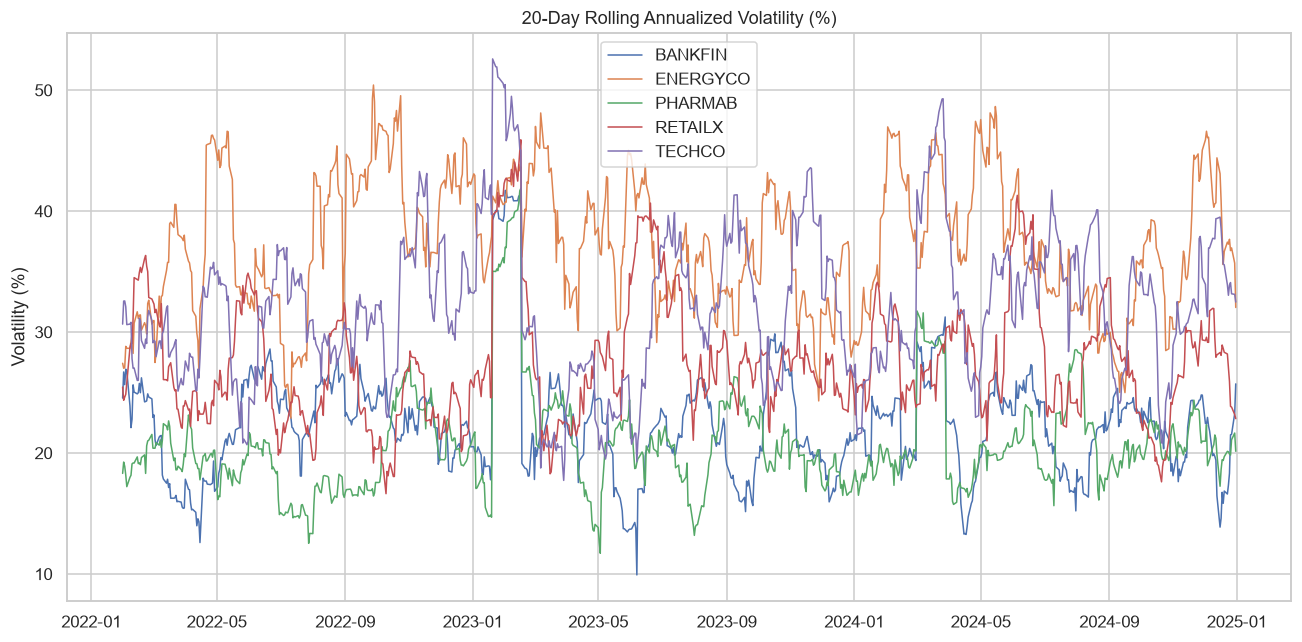

In [11]:
plt.figure(figsize=(12, 6))
for i, ticker in enumerate(tickers):
    g = df[df["Ticker"] == ticker]
    plt.plot(g["Date"], g["Volatility_20D"] * 100, label=ticker, color=colors[i], linewidth=1)
plt.title("20-Day Rolling Annualized Volatility (%)")
plt.ylabel("Volatility (%)")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Correlation Analysis

If two stocks move together (high positive correlation), holding both
doesn't diversify risk much. Let's check how correlated daily returns are
across our 5 stocks.

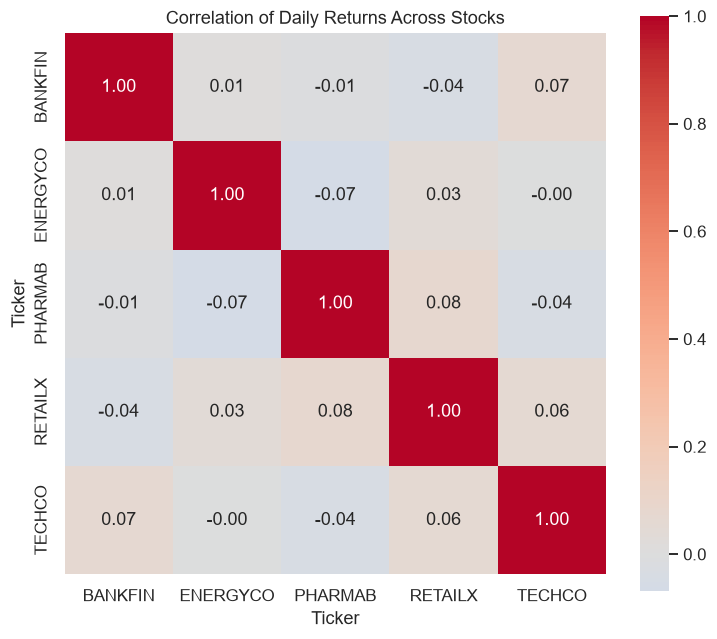

In [12]:
pivot = df.pivot(index="Date", columns="Ticker", values="Daily_Return")
corr = pivot.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True)
plt.title("Correlation of Daily Returns Across Stocks")
plt.tight_layout()
plt.show()


**Observation:** Correlations are generally low-to-moderate across
sectors, which makes sense — TECHCO (Technology) and PHARMAB (Healthcare)
respond to very different market drivers than ENERGYCO (Energy). This
matters for portfolio construction: combining low-correlation stocks
reduces overall portfolio risk.

## 7. Risk-Adjusted Return: Sharpe Ratio & Max Drawdown

Raw return is misleading on its own. Two key risk-adjusted metrics:

- **Sharpe Ratio** = (Annualized Return − Risk-Free Rate) / Annualized Volatility
  → higher is better; it tells you how much return you're getting *per unit of risk taken*.
- **Max Drawdown** = the largest peak-to-trough decline over the period
  → tells you the worst-case pain an investor would have felt holding the stock.


In [13]:
def compute_risk_metrics(df):
    rows = []
    for ticker, g in df.groupby("Ticker"):
        daily_ret = g["Daily_Return"].dropna()
        ann_return = daily_ret.mean() * 252
        ann_vol = daily_ret.std() * np.sqrt(252)
        sharpe = (ann_return - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else np.nan

        cum = (1 + daily_ret).cumprod()
        running_max = cum.cummax()
        drawdown = (cum - running_max) / running_max
        max_drawdown = drawdown.min()

        total_return = g["Cumulative_Return"].iloc[-1]

        rows.append({
            "Ticker": ticker,
            "Sector": g["Sector"].iloc[0],
            "Total_Return_%": round(total_return * 100, 2),
            "Annualized_Return_%": round(ann_return * 100, 2),
            "Annualized_Volatility_%": round(ann_vol * 100, 2),
            "Sharpe_Ratio": round(sharpe, 2),
            "Max_Drawdown_%": round(max_drawdown * 100, 2),
        })
    return pd.DataFrame(rows).sort_values("Sharpe_Ratio", ascending=False).reset_index(drop=True)

risk_df = compute_risk_metrics(df)
risk_df


,Ticker,Sector,Total_Return_%,Annualized_Return_%,Annualized_Volatility_%,Sharpe_Ratio,Max_Drawdown_%
0,PHARMAB,Healthcare,101.43,24.86,21.19,0.94,-24.47
1,TECHCO,Technology,46.29,17.53,32.49,0.39,-40.52
2,ENERGYCO,Energy,-32.38,-5.68,37.32,-0.29,-56.91
3,BANKFIN,Finance,-12.89,-1.85,22.84,-0.30,-30.27
4,RETAILX,Retail,-44.68,-15.21,27.83,-0.73,-63.15


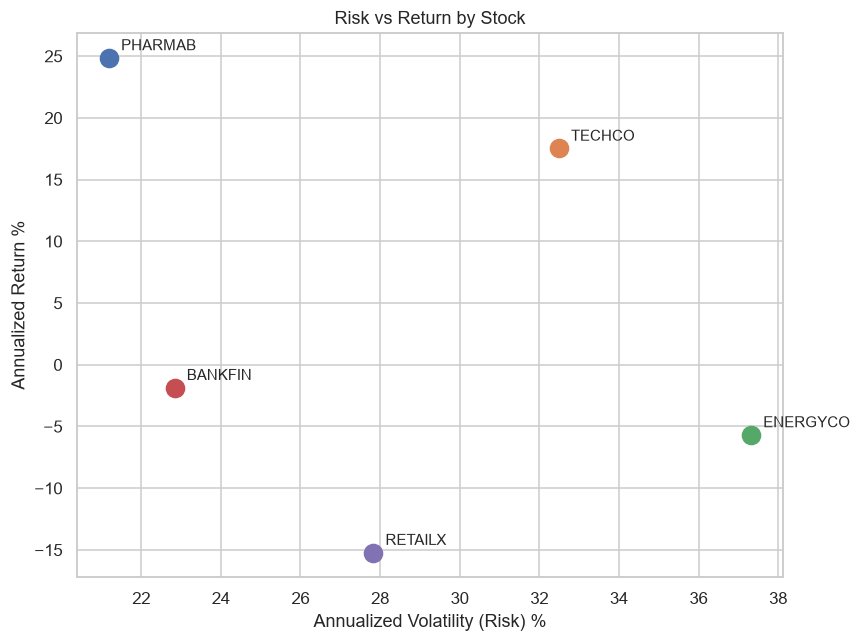

In [14]:
plt.figure(figsize=(8, 6))
for i, row in risk_df.iterrows():
    plt.scatter(row["Annualized_Volatility_%"], row["Annualized_Return_%"], s=140)
    plt.annotate(row["Ticker"],
                 (row["Annualized_Volatility_%"], row["Annualized_Return_%"]),
                 textcoords="offset points", xytext=(8, 5), fontsize=10)
plt.xlabel("Annualized Volatility (Risk) %")
plt.ylabel("Annualized Return %")
plt.title("Risk vs Return by Stock")
plt.tight_layout()
plt.show()


**Key insight:** PHARMAB delivers the best risk-adjusted return
(highest Sharpe Ratio) — solid returns *without* the highest volatility.
TECHCO has strong returns but much higher volatility, meaning a bumpier
ride to get there. ENERGYCO and RETAILX are the weakest performers on both
absolute and risk-adjusted terms over this period.

## 8. Technical Deep-Dive: RSI, MACD & Bollinger Bands

For the best risk-adjusted performer, let's look at current technical
signals — the kind of indicators traders check before making a buy/sell
decision.

- **RSI (Relative Strength Index):** above 70 = potentially overbought,
  below 30 = potentially oversold
- **MACD:** when the MACD line crosses above its signal line, it's often
  read as bullish momentum (and vice versa)
- **Bollinger Bands:** price touching the upper band suggests the stock
  may be overextended short-term; touching the lower band suggests it may
  be oversold


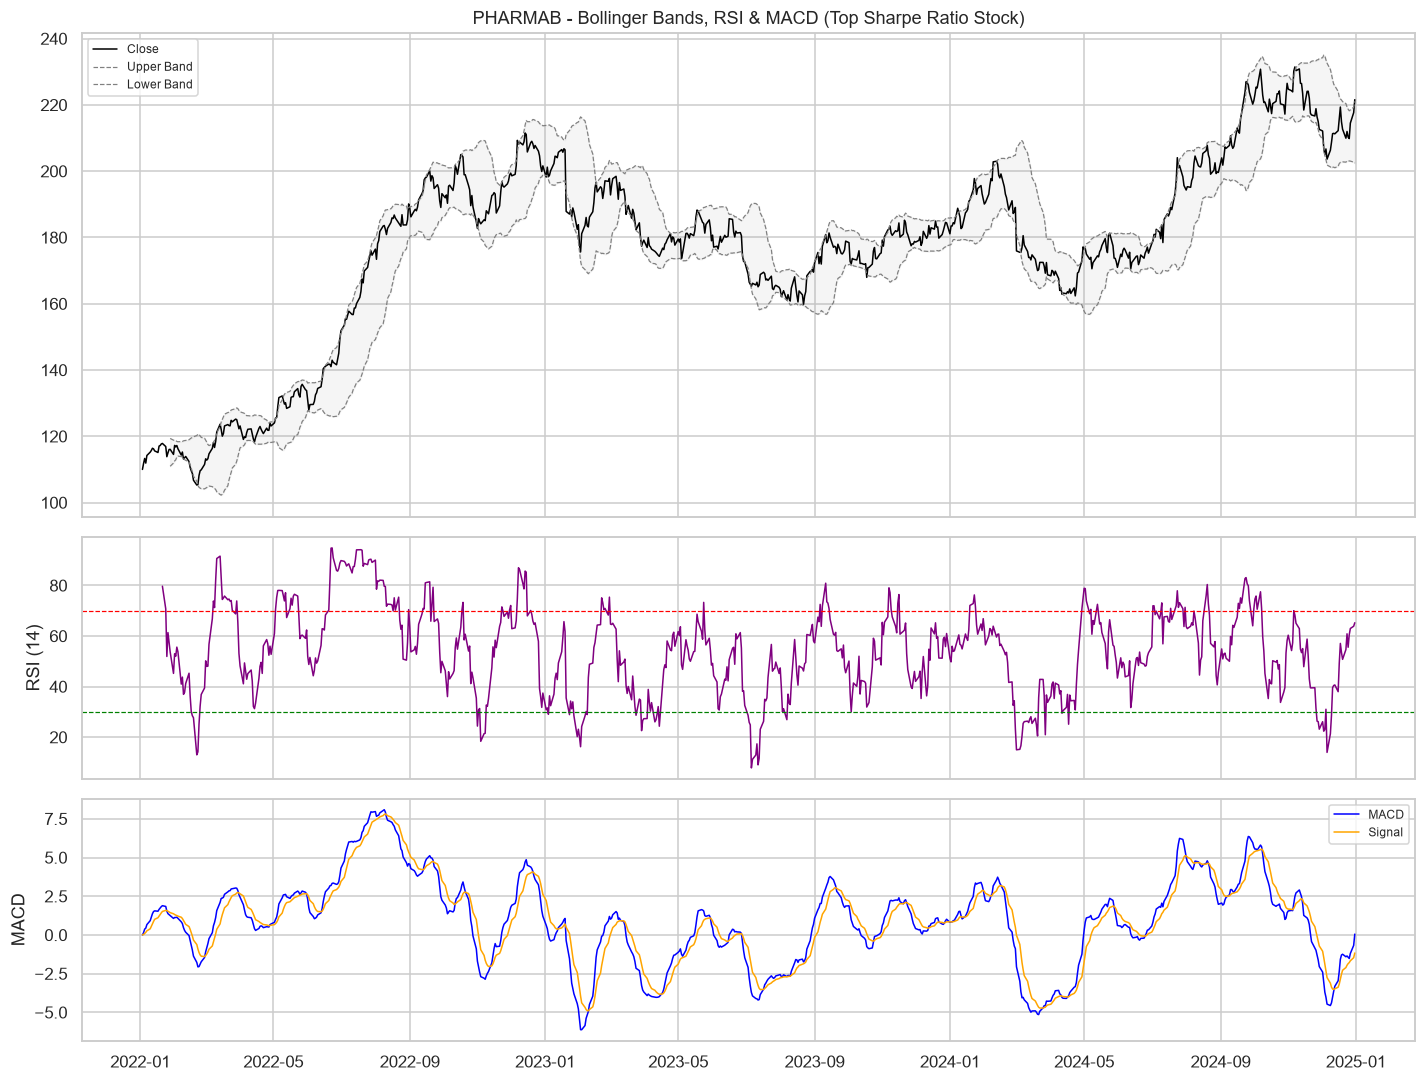

In [15]:
top_ticker = risk_df.iloc[0]["Ticker"]
g = df[df["Ticker"] == top_ticker]

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1, 1]})

axes[0].plot(g["Date"], g["Close"], label="Close", color="black", linewidth=1)
axes[0].plot(g["Date"], g["BB_Upper"], label="Upper Band", color="grey", linestyle="--", linewidth=0.8)
axes[0].plot(g["Date"], g["BB_Lower"], label="Lower Band", color="grey", linestyle="--", linewidth=0.8)
axes[0].fill_between(g["Date"], g["BB_Lower"], g["BB_Upper"], alpha=0.08, color="grey")
axes[0].set_title(f"{top_ticker} - Bollinger Bands, RSI & MACD (Top Sharpe Ratio Stock)")
axes[0].legend(fontsize=8)

axes[1].plot(g["Date"], g["RSI_14"], color="purple", linewidth=1)
axes[1].axhline(70, color="red", linestyle="--", linewidth=0.8)
axes[1].axhline(30, color="green", linestyle="--", linewidth=0.8)
axes[1].set_ylabel("RSI (14)")

axes[2].plot(g["Date"], g["MACD"], label="MACD", color="blue", linewidth=1)
axes[2].plot(g["Date"], g["MACD_Signal"], label="Signal", color="orange", linewidth=1)
axes[2].set_ylabel("MACD")
axes[2].legend(fontsize=8)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.show()


## 9. Current Trend Classification (All Stocks)

Finally, let's classify each stock's *current* trend state using the
relationship between price, SMA50, and SMA200 — a simple, explainable rule
set an analyst could hand to a non-technical stakeholder.

In [16]:
def classify_trend(df):
    latest = df.sort_values("Date").groupby("Ticker").tail(1)
    trends = []
    for _, row in latest.iterrows():
        if row["SMA50"] > row["SMA200"] and row["Close"] > row["SMA50"]:
            trend = "Strong Uptrend"
        elif row["SMA50"] > row["SMA200"]:
            trend = "Mild Uptrend"
        elif row["SMA50"] < row["SMA200"] and row["Close"] < row["SMA50"]:
            trend = "Strong Downtrend"
        else:
            trend = "Sideways / Consolidating"
        trends.append({"Ticker": row["Ticker"], "Current_Trend": trend,
                        "RSI_14": round(row["RSI_14"], 1)})
    return pd.DataFrame(trends)

trend_df = classify_trend(df)
trend_df


,Ticker,Current_Trend,RSI_14
0,RETAILX,Strong Downtrend,33.3
1,ENERGYCO,Strong Downtrend,59.9
2,BANKFIN,Sideways / Consolidating,55.1
3,PHARMAB,Strong Uptrend,65.2
4,TECHCO,Sideways / Consolidating,67.3


## 10. Summary of Findings

| Stock | Sector | Total Return | Sharpe Ratio | Current Trend |
|---|---|---|---|---|
| PHARMAB | Healthcare | +101.4% | **0.94 (best)** | Strong Uptrend |
| TECHCO | Technology | +46.3% | 0.39 | Sideways |
| BANKFIN | Finance | -12.9% | -0.30 | Sideways |
| ENERGYCO | Energy | -32.4% | -0.29 | Strong Downtrend |
| RETAILX | Retail | -44.7% | -0.73 (worst) | Strong Downtrend |

### Key Takeaways
1. **PHARMAB was the standout performer** — highest total return *and* the
   best risk-adjusted return (Sharpe Ratio 0.94), with the shallowest max
   drawdown of the three positive-return stocks. It's currently in a
   confirmed uptrend (price and SMA50 both above SMA200).
2. **TECHCO delivered strong absolute returns but with much higher
   volatility** (32% annualized vs. PHARMAB's 21%) — a much bumpier
   holding experience for a similar underlying return profile.
3. **RETAILX and ENERGYCO underperformed on every metric** — negative
   total return, negative Sharpe Ratio, and the two largest drawdowns
   (-63% and -57% respectively). Both are in a confirmed downtrend as of
   the latest data.
4. **Correlation across sectors is low-to-moderate**, suggesting a
   portfolio spread across these sectors would have provided meaningful
   diversification benefit versus concentrating in one.

### Recommendation
Based purely on this 3-year historical window, **PHARMAB offers the best
risk-adjusted opportunity**, and **RETAILX/ENERGYCO warrant caution** given
their sustained downtrends and weak risk-adjusted returns. Any live
investment decision should combine this historical technical view with
fundamental analysis (earnings, sector outlook, macro conditions) — trend
and momentum indicators describe *what has happened*, not guarantee *what
will happen next*.

---
*This analysis is for educational/portfolio purposes only and is not
financial advice.*
